# 01 — Data Loading & Exploratory Data Analysis

Loads the GRDC daily discharge record for the Simme at Oberried/Lenk (station 6935331),
performs basic quality checks, extracts the Annual Maximum Series (AMS), and exports
`data/processed/annual_summary.csv` for use by downstream notebooks.

| # | Step | Lecture Reference |
|---|------|------------------|
| 1 | Raw discharge loading & QC | — |
| 2 | GLOF event catalogue | — |
| 3 | Annual block maxima extraction | Module 2, §4.1 |
| 4 | Descriptive statistics | Module 1, §1.2 |
| 5 | Time series + annual maxima plot | — |
| 6 | Export processed data | — |

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from utils import load_grdc_discharge, extract_annual_maxima, GLOF_DATES, GLOF_WINDOW

FIGS     = Path('../figures/01_eda')
DATA_OUT = Path('../data/processed')
FIGS.mkdir(exist_ok=True)
DATA_OUT.mkdir(exist_ok=True)

## 1 — Raw Discharge Loading & Quality Control

In [2]:
Q_daily = load_grdc_discharge()

print(f'Station:  GRDC 6935331 — Simme at Oberried/Lenk')
print(f'Period:   {Q_daily.index[0].date()}  to  {Q_daily.index[-1].date()}')
print(f'Days:     {len(Q_daily):,}  |  NaN: {Q_daily.isna().sum()}')
print(f'Range:    {Q_daily.min():.2f} – {Q_daily.max():.1f} m³/s  |  mean: {Q_daily.mean():.2f} m³/s')

Station:  GRDC 6935331 — Simme at Oberried/Lenk
Period:   1944-01-01  to  2020-12-31
Days:     28,125  |  NaN: 0
Range:    0.04 – 21.1 m³/s  |  mean: 2.16 m³/s


## 2 — GLOF Event Catalogue

Confirmed outburst dates from gletschersee-lenk.ch, Simmentalzeitung, 20min.ch, and TC (2021).
2016 excluded: no documented major outburst. Each event is masked with a ±5-day window
in the homogeneity analysis (Notebook 03).

In [3]:
print(f'GLOF events documented ({len(GLOF_DATES)} years, ±{GLOF_WINDOW}-day window):')
for yr, dt in GLOF_DATES.items():
    q_on_date = Q_daily.get(dt, float('nan'))
    print(f'  {yr}: {dt.date()}   Q on GLOF day = {q_on_date:.2f} m³/s')

GLOF events documented (8 years, ±5-day window):
  2011: 2011-07-27   Q on GLOF day = 2.46 m³/s
  2012: 2012-07-16   Q on GLOF day = 14.56 m³/s
  2013: 2013-08-02   Q on GLOF day = 14.99 m³/s
  2014: 2014-08-07   Q on GLOF day = 19.00 m³/s
  2015: 2015-08-01   Q on GLOF day = 10.11 m³/s
  2016: 2016-08-28   Q on GLOF day = 11.97 m³/s
  2017: 2017-07-19   Q on GLOF day = 11.79 m³/s
  2018: 2018-07-27   Q on GLOF day = 14.62 m³/s


## 3 — Annual Block Maxima (Module 2, §4.1)

In [4]:
Q_ann = extract_annual_maxima(Q_daily)
# Record date of the annual maximum for each year
Q_ann_date = Q_daily.resample('A').apply(lambda s: s.idxmax())
Q_ann_date.index = Q_ann_date.index.year

glof_years = set(GLOF_DATES.keys())

annual = pd.DataFrame({
    'Q_max':      Q_ann,
    'Q_max_date': Q_ann_date,
    'is_glof':    [yr in glof_years for yr in Q_ann.index],
})
annual.index.name = 'year'

n = len(annual)
print(f'Annual Maximum Series: n={n} years  ({annual.index[0]}–{annual.index[-1]})')
print(f'GLOF years in AMS: {sorted(glof_years & set(annual.index))}')

Annual Maximum Series: n=77 years  (1944–2020)
GLOF years in AMS: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


C:\Users\zehnd\AppData\Local\Temp\ipykernel_36324\2539140133.py:3: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  Q_ann_date = Q_daily.resample('A').apply(lambda s: s.idxmax())


## 4 — Descriptive Statistics (Module 1, §1.2)

In [5]:
Q = annual['Q_max']
Q_no_glof = Q[~annual['is_glof']]
Q_glof    = Q[ annual['is_glof']]

print(f'                   Full series   Non-GLOF years   GLOF years')
print(f'n                  {len(Q):>11}   {len(Q_no_glof):>14}   {len(Q_glof):>10}')
print(f'Mean (m³/s)        {Q.mean():>11.2f}   {Q_no_glof.mean():>14.2f}   {Q_glof.mean():>10.2f}')
print(f'Std  (m³/s)        {Q.std():>11.2f}   {Q_no_glof.std():>14.2f}   {Q_glof.std():>10.2f}')
print(f'Median (m³/s)      {Q.median():>11.2f}   {Q_no_glof.median():>14.2f}   {Q_glof.median():>10.2f}')
print(f'Min / Max (m³/s)   {Q.min():.2f} / {Q.max():.2f}   {Q_no_glof.min():.2f} / {Q_no_glof.max():.2f}   {Q_glof.min():.2f} / {Q_glof.max():.2f}')

print('\nTop 10 annual maxima:')
print(annual['Q_max'].nlargest(10).to_frame().join(annual[['Q_max_date', 'is_glof']]).to_string())

                   Full series   Non-GLOF years   GLOF years
n                           77               69            8
Mean (m³/s)              11.52            11.07        15.37
Std  (m³/s)               2.65             2.18         3.39
Median (m³/s)            10.80            10.70        14.78
Min / Max (m³/s)   8.03 / 21.09   8.03 / 18.65   10.11 / 21.09

Top 10 annual maxima:
       Q_max Q_max_date  is_glof
year                            
2014  21.087 2014-08-11     True
2018  19.236 2018-07-28     True
1982  18.646 1982-07-25    False
2005  17.056 2005-08-22    False
1945  17.000 1945-07-25    False
1998  15.175 1998-08-23    False
2011  15.078 2011-07-12     True
2013  14.986 2013-08-02     True
2012  14.565 2012-07-16     True
1994  14.125 1994-06-27    False


## 5 — Time Series & Annual Maxima Plot

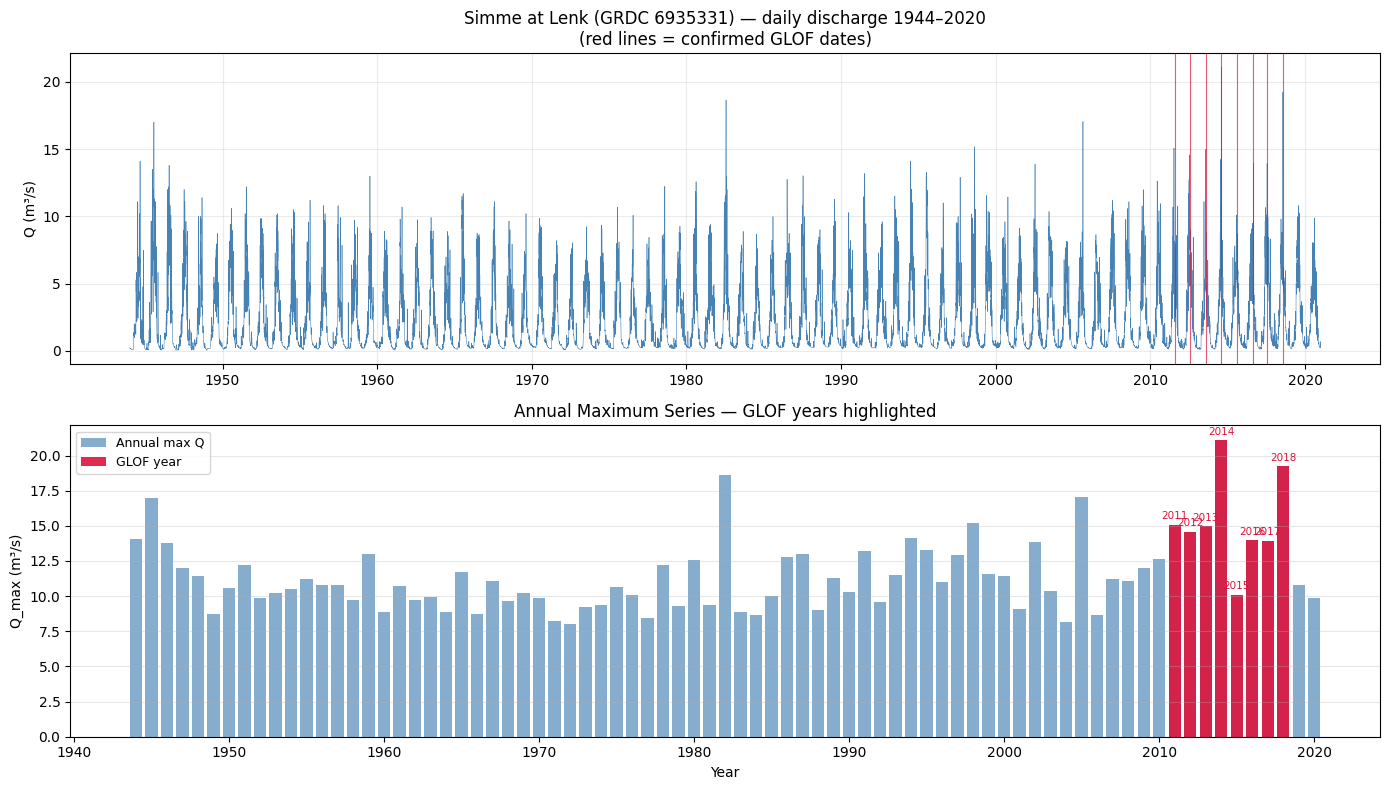

Saved -> figures/01_eda/01_discharge_overview.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Panel A: daily discharge
ax = axes[0]
ax.plot(Q_daily.index, Q_daily.values, lw=0.4, color='steelblue')
for dt in GLOF_DATES.values():
    ax.axvline(dt, color='crimson', lw=0.8, alpha=0.7)
ax.set_ylabel('Q (m³/s)')
ax.set_title('Simme at Lenk (GRDC 6935331) — daily discharge 1944–2020\n(red lines = confirmed GLOF dates)')
ax.grid(alpha=0.25)

# Panel B: annual maxima bar chart
ax2 = axes[1]
glof_mask = annual['is_glof']
ax2.bar(annual.index, annual['Q_max'], color='steelblue', alpha=0.65, label='Annual max Q')
ax2.bar(
    annual.index[glof_mask], annual.loc[glof_mask, 'Q_max'],
    color='crimson', alpha=0.9, label='GLOF year'
)
for yr in annual.index[glof_mask]:
    ax2.text(yr, annual.loc[yr, 'Q_max'] + 0.25, str(yr),
             ha='center', va='bottom', fontsize=7.5, color='crimson')
ax2.set_xlabel('Year')
ax2.set_ylabel('Q_max (m³/s)')
ax2.set_title('Annual Maximum Series — GLOF years highlighted')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / '01_discharge_overview.png', dpi=150)
plt.show()
print('Saved -> figures/01_eda/01_discharge_overview.png')

## 6 — Export Processed Data

In [7]:
annual.to_csv(DATA_OUT / 'annual_summary.csv')
print(f'Saved -> data/processed/annual_summary.csv  ({len(annual)} rows)')

Saved -> data/processed/annual_summary.csv  (77 rows)
